In [126]:
!pip install ucimlrepo
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install xgboost
!pip install tqdm


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, QuantileTransformer
import xgboost as xgb

IMAGES_DIR = Path('images')
IMAGES_DIR.mkdir(exist_ok=True)


def save_plot(filename):
    plt.savefig(IMAGES_DIR / filename, dpi=300, bbox_inches='tight')


In [128]:
def write_variable_descriptions(variables: pd.DataFrame, output_path: str) -> None:
    lines = []

    if "name" in variables.columns and "description" in variables.columns:
        for _, row in variables.iterrows():
            name = row["name"]
            description = row["description"]

            if pd.isna(description):
                description = "No description available."

            lines.append(f"{name}:")
            lines.append(str(description).strip())
            lines.append("")
    else:
        # Fallback: store the full table if the expected columns are unavailable.
        lines.append(variables.to_string(index=False))

    Path(output_path).write_text("\n".join(lines).rstrip() + "\n", encoding="utf-8")


# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# variable information 
print(bank_marketing.variables) 

# variable information
write_variable_descriptions(bank_marketing.variables, "variable_information.txt")
print("Saved variable descriptions to variable_information.txt")

# store data in csv file, put X,y together
df = pd.concat([X, y], axis=1)
df.to_csv('bank_marketing.csv', index=False)

           name     role         type      demographic  \
0           age  Feature      Integer              Age   
1           job  Feature  Categorical       Occupation   
2       marital  Feature  Categorical   Marital Status   
3     education  Feature  Categorical  Education Level   
4       default  Feature       Binary              NaN   
5       balance  Feature      Integer              NaN   
6       housing  Feature       Binary              NaN   
7          loan  Feature       Binary              NaN   
8       contact  Feature  Categorical              NaN   
9   day_of_week  Feature         Date              NaN   
10        month  Feature         Date              NaN   
11     duration  Feature      Integer              NaN   
12     campaign  Feature      Integer              NaN   
13        pdays  Feature      Integer              NaN   
14     previous  Feature      Integer              NaN   
15     poutcome  Feature  Categorical              NaN   
16            

In [129]:
# Data Preprocessing Step 1: handle missing and inconsistent values

# Expected Values for each categorical column
expected_job = {
    'admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management',
    'retired', 'self-employed', 'services', 'student', 'technician',
    'unemployed', 'unknown'
}

expected_martial = {
    'single', 'married', 'divorced', 'unknown'
}

expected_education = {
    'primary', 'secondary', 'tertiary', 'unknown'
}

expected_contact = {
    'cellular', 'telephone', 'unknown'
}

expected_poutcome = {
    'unknown', 'other', 'failure', 'success'
}

binary_columns = {
    'yes', 'no'
}

# 1. Age: check if there are any missing values or inconsistent(non integer or negative)
# check if there are any missing values
missing_age = df['age'].isnull().sum()
print(f"Number of missing age values: {missing_age}")

# check if there are any inconsistent values (negative or non integer)
inconsistent_age = df[~df['age'].isin(range(0, 100))]
print(f"Number of inconsistent age values: {len(inconsistent_age)}")

# 2. Job: check if there are any missing values    
# or inconsistent(null values or unexpected job)
missing_job = df['job'].isnull().sum()
print(f"Number of missing job values: {missing_job}")

# check how many non-null values are expected
expected_job = df['job'].isin(expected_job).sum()
print(f"Number of expected job values: {expected_job}")

# drop the missing job column
df = df.dropna(subset=['job'])

# 3. Martial: check if there are any missing values or 
# inconsistent(non string or unexpected martial)

# check how many martial column is missing
missing_martial = df['marital'].isnull().sum()
print(f"Number of missing martial values: {missing_martial}")

# check how many non-null values are expected
expected_martial = df['marital'].isin(expected_martial).sum()
print(f"Number of expected martial values: {expected_martial}")

# 4. Education: check if there are any missing values or 
# inconsistent(non string or unexpected education)

# check how many education column is missing
missing_education = df['education'].isnull().sum()
print(f"Number of missing education values: {missing_education}")

# check how many non-null values are expected
expected_education = df['education'].isin(expected_education).sum()
print(f"Number of expected education values: {expected_education}")

# drop the missing education column
df.dropna(subset=['education'], inplace=True)

missing_education = df['education'].isnull().sum()
print(f"Number of missing education values: {missing_education}")

# 5. Default: check if there are any missing values or 
# inconsistent(non string or unexpected default)

# check how many default column is missing
missing_default = df['default'].isnull().sum()
print(f"Number of missing default values: {missing_default}")

# check how many non-null values are expected
expected_default = df['default'].isin(binary_columns).sum()
print(f"Number of expected default values: {expected_default}")

# 6. Balance: check if there are any missing values or 
# inconsistent(non integer or negative)

# check if there are any missing values
missing_balance = df['balance'].isnull().sum()
print(f"Number of missing balance values: {missing_balance}")

# check if there are any non-integer, it can be negative
non_integer_balance = df[~df['balance'].isin(range(-10000000, 10000000))]
print(f"Number of non-integer balance values: {len(non_integer_balance)}")

if len(non_integer_balance) > 0:
    print(f"There are {len(non_integer_balance)} non-integer balance values")
else:
    print("There are no non-integer balance values")

# 7. Housing: check if there are any missing values or 
# inconsistent(non string or unexpected housing)

# check how many housing column is missing
missing_housing = df['housing'].isnull().sum()
print(f"Number of missing housing values: {missing_housing}")

# check how many non-null values are expected
expected_housing = df['housing'].isin(binary_columns).sum()
print(f"Number of expected housing values: {expected_housing}")

# 8. Loan: check if there are any missing values or 
# inconsistent(non string or unexpected loan)

# check how many loan column is missing
missing_loan = df['loan'].isnull().sum()
print(f"Number of missing loan values: {missing_loan}")

# check how many non-null values are expected
expected_loan = df['loan'].isin(binary_columns).sum()
print(f"Number of expected loan values: {expected_loan}")

# 9. Contact: check if there are any missing values or 
# inconsistent(non string or unexpected contact)
# check how many contact column is missing (NaN or empty strings)
missing_contact = (df['contact'].isnull() | (df['contact'] == '')).sum()
print(f"Number of missing contact values: {missing_contact}")

# replace the missing contact column with 'unknown' tag
df['contact'] = df['contact'].replace('', 'unknown').fillna('unknown')

# verify the final count of 'expected' values including 'unknown'
expected_contact_count = df['contact'].isin(expected_contact).sum()
print(f"Number of expected contact values: {expected_contact_count}")

# verify no more missing values
missing_contact_after = (df['contact'].isnull() | (df['contact'] == '')).sum()
print(f"Number of missing contact values after filling: {missing_contact_after}")

# 10. Day_of_week & Month: check if there are any missing values or 
# inconsistent(non string or unexpected day_of_week or month)
# check missing values first
missing_day_of_week = df['day_of_week'].isnull().sum()
print(f"Number of missing day_of_week values: {missing_day_of_week}")

missing_month = df['month'].isnull().sum()
print(f"Number of missing month values: {missing_month}")

# then check if the date is valid since each month has a different number of days
# we can use the datetime module to check if the date is valid

expected_month = {
    'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'
}

expected_day_of_month = {
    'jan': 31, 'feb': 28, 'mar': 31, 'apr': 30, 'may': 31, 'jun': 30, 
    'jul': 31, 'aug': 31, 'sep': 30, 'oct': 31, 'nov': 30, 'dec': 31
}

# First check if the month is in expected_month
missing_month = df['month'].isin(expected_month).sum()
print(f"Number of missing month values: {missing_month}")

# Given the month of each row, check if the day of month is valid
# for each item, retrive month and set range (1, expected_day_of_month[month] + 1)
# check if the day of month is in the range
invalid_day_of_month = 0
for index, row in df.iterrows():
    month = row['month']
    day_of_month = row['day_of_week']
    if month in expected_day_of_month:
        if day_of_month > expected_day_of_month[month]:
            print(f"Invalid day of month for {month}: {day_of_month}")
            invalid_day_of_month += 1

print(f"Number of invalid day of month: {invalid_day_of_month}")

# 11. Duration: check if there are any missing values or 
# inconsistent(non integer or negative)

# check if there are any missing values
missing_duration = df['duration'].isnull().sum()
print(f"Number of missing duration values: {missing_duration}")

# check if there are any non-integer, it can be negative
non_integer_duration = df[~df['duration'].isin(range(0,1000000))]
print(f"Number of non-integer duration values: {len(non_integer_duration)}")

if len(non_integer_duration) > 0:
    print(f"There are {len(non_integer_duration)} non-integer or negative duration values")
    print(non_integer_duration)
else:
    print("There are no non-integer duration values")

# 12. Campaign: check if there are any missing values or
# inconsistent(non integer or negative)
# campaign: check if there are any missing values or 
# inconsistent(non integer or negative)

# check if there are any missing values
missing_campaign = df['campaign'].isnull().sum()
print(f"Number of missing campaign values: {missing_campaign}")

# check if there are any non-integer, it can be negative
non_integer_campaign = df[~df['campaign'].isin(range(0,1000000))]
print(f"Number of non-integer campaign values: {len(non_integer_campaign)}")

if len(non_integer_campaign) > 0:
    print(f"There are {len(non_integer_campaign)} non-integer campaign values")
    print(non_integer_campaign)
else:
    print("There are no non-integer campaign values")

# 13. Pdays: check if there are any missing values or 
# inconsistent(non integer or negative)
# check if there are any missing values
missing_pdays = df['pdays'].isnull().sum()
print(f"Number of missing pdays values: {missing_pdays}")

# check if there are any non-integer, it can be negative
non_integer_pdays = df[~df['pdays'].isin(range(-1, 1000000))]
print(f"Number of non-integer pdays values: {len(non_integer_pdays)}")

if len(non_integer_pdays) > 0:
    print(f"There are {len(non_integer_pdays)} non-integer or negative pdays values")
    # print(non_integer_pdays)
else:
    print("There are no non-integer pdays values")

# 14. Previous: check if there are any missing values or 
# inconsistent(non integer or negative)
# check if there are any missing values
missing_previous = df['previous'].isnull().sum()
print(f"Number of missing previous values: {missing_previous}")

# check if there are any non-string values
non_string_previous = df[~df['previous'].isin(range(0,1000000))]

if len(non_string_previous) > 0:
    print(f"There are {len(non_string_previous)} non-string previous values")
    print(non_string_previous)
else:
    print("There are no non-string previous values")

# 15. Poutcome: check if there are any missing values or 
# inconsistent(non string or unexpected poutcome)
# check if there are any missing values
missing_poutcome = df['poutcome'].isnull().sum()
print(f"Number of missing poutcome values: {missing_poutcome}")

# check if there are any non-string values
non_string_poutcome = df[~df['poutcome'].isin(expected_poutcome)]

if len(non_string_poutcome) > 0:
    print(f"There are {len(non_string_poutcome)} non-string poutcome values")
    # print(non_string_poutcome)
else:
    print("There are no non-string poutcome values")

# replace the missing poutcome values with 'unknown' tag
df['poutcome'] = df['poutcome'].fillna('unknown')

# 16. Target: check if there are any missing values or 
# inconsistent(non string or unexpected target)
# check if there are any missing values
missing_target = df['y'].isnull().sum()
print(f"Number of missing target values: {missing_target}")

# check if there are any non-string values
non_string_target = df[~df['y'].isin(binary_columns)]

if len(non_string_target) > 0:
    print(f"There are {len(non_string_target)} unexpected target values")
else:
    print("There are no unexpected target values")

Number of missing age values: 0
Number of inconsistent age values: 0
Number of missing job values: 288
Number of expected job values: 44923
Number of missing martial values: 0
Number of expected martial values: 44923
Number of missing education values: 1730
Number of expected education values: 43193
Number of missing education values: 0
Number of missing default values: 0
Number of expected default values: 43193
Number of missing balance values: 0
Number of non-integer balance values: 0
There are no non-integer balance values
Number of missing housing values: 0
Number of expected housing values: 43193
Number of missing loan values: 0
Number of expected loan values: 43193
Number of missing contact values: 12286
Number of expected contact values: 43193
Number of missing contact values after filling: 0
Number of missing day_of_week values: 0
Number of missing month values: 0
Number of missing month values: 43193
Number of invalid day of month: 0
Number of missing duration values: 0
Number

In [130]:
# Data Preprocessing Step 2: Encoding Categorical Variables

# 1. Binary Encoding (0/1) for: default, housing, loan, and the target y.
# Binary Encoding is used for features with only two categories to save space and maintain simplicity.
binary_mapping = {'yes': 1, 'no': 0}
df['default'] = df['default'].map(binary_mapping)
df['housing'] = df['housing'].map(binary_mapping)
df['loan'] = df['loan'].map(binary_mapping)
df['y'] = df['y'].map(binary_mapping)

# 2. Convert day_of_week (day of month) and month into a single day_of_year feature.
month_offsets = {
    'jan': 0, 'feb': 31, 'mar': 59, 'apr': 90, 'may': 120, 'jun': 151,
    'jul': 181, 'aug': 212, 'sep': 243, 'oct': 273, 'nov': 304, 'dec': 334
}
df['day_of_year'] = df['month'].map(month_offsets) + df['day_of_week'].astype(int)
df = df.drop(columns=['day_of_week', 'month'])

job_groups = {
     'admin.': 'professional', 'management': 'professional', 'technician': 'professional', 
     'self-employed': 'professional', 'entrepreneur': 'professional',
     'blue-collar': 'manual', 'services': 'manual', 'housemaid': 'manual',
     'retired': 'other', 'student': 'other', 'unemployed': 'other', 'unknown': 'other'
}

df['job'] = df['job'].map(job_groups)

# 3. One-Hot Encoding for remaining nominal variables.
nominal_cols = ['job', 'marital', 'education', 'contact', 'poutcome']
df = pd.get_dummies(df, columns=nominal_cols, dtype=int)

# Verify the encoding
print("Final Columns:", df.columns.tolist())
df.head()

# store the encoded table in a new csv file
# df = df.drop(columns=['day_of_year'])
df.to_csv('encoded_bank_marketing.csv', index=False)


Final Columns: ['age', 'default', 'balance', 'housing', 'loan', 'duration', 'campaign', 'pdays', 'previous', 'y', 'day_of_year', 'job_manual', 'job_other', 'job_professional', 'marital_divorced', 'marital_married', 'marital_single', 'education_primary', 'education_secondary', 'education_tertiary', 'contact_cellular', 'contact_telephone', 'contact_unknown', 'poutcome_failure', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']


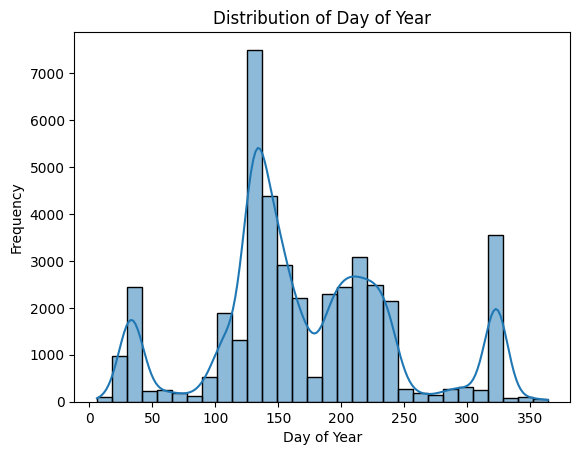

Features after day_of_year transformations:
['age', 'default', 'balance', 'housing', 'loan', 'duration', 'campaign', 'pdays', 'previous', 'y', 'job_manual', 'job_other', 'job_professional', 'marital_divorced', 'marital_married', 'marital_single', 'education_primary', 'education_secondary', 'education_tertiary', 'contact_cellular', 'contact_telephone', 'contact_unknown', 'poutcome_failure', 'poutcome_other', 'poutcome_success', 'poutcome_unknown', 'day_sin', 'day_cos', 'season_autumn', 'season_spring', 'season_summer', 'season_winter']


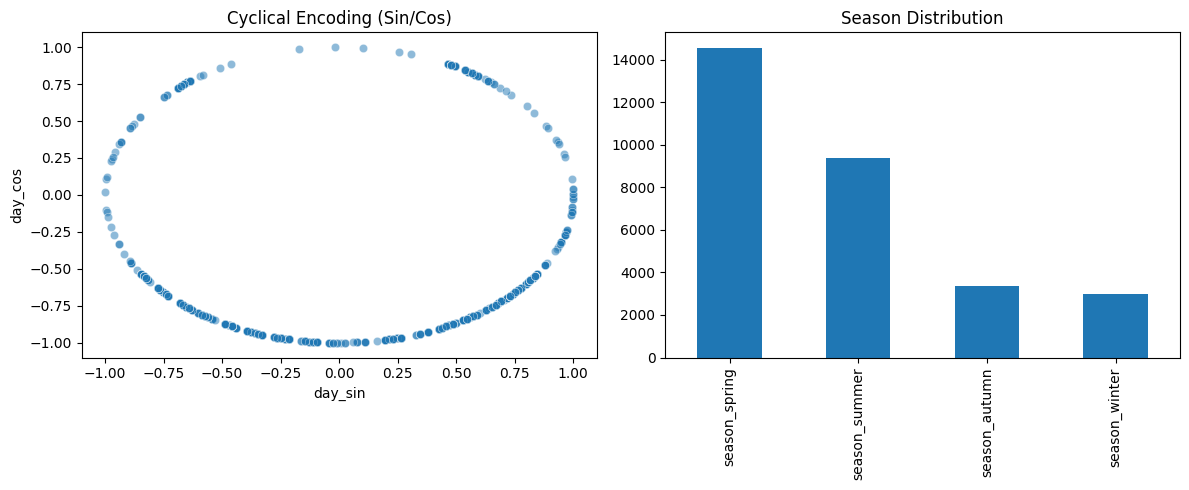

Training set size: (30235, 32)
Validation set size: (6479, 32)
Test set size: (6479, 32)


In [156]:
# Data Preprocessing Step 4: Data Splitting (70/15/15)
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp (which will be split into val and test)
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)

# Second split: 50% of temp_df for validation, 50% for test (0.5 * 0.3 = 0.15 each)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

# Day of year: Seasonal and Cyclical Encoding

# provide a original distribution of day_of_year
sns.histplot(df['day_of_year'], bins=30, kde=True)
plt.title('Distribution of Day of Year')
plt.xlabel('Day of Year')
plt.ylabel('Frequency')

save_plot('day_of_year_distribution.png')
plt.show()

def get_season(day):
    if 80 <= day <= 171: return 'spring'
    elif 172 <= day <= 263: return 'summer'
    elif 264 <= day <= 354: return 'autumn'
    else: return 'winter'

for df_temp in [train_df, val_df, test_df]:
    # 1. Seasonal Encoding
    df_temp['season'] = df_temp['day_of_year'].apply(get_season)
    
    # 2. Cyclical Encoding
    df_temp['day_sin'] = np.sin(2 * np.pi * df_temp['day_of_year'] / 365)
    df_temp['day_cos'] = np.cos(2 * np.pi * df_temp['day_of_year'] / 365)

# One-hot encode the season feature
train_df = pd.get_dummies(train_df, columns=['season'], prefix='season', dtype=int)
val_df = pd.get_dummies(val_df, columns=['season'], prefix='season', dtype=int)
test_df = pd.get_dummies(test_df, columns=['season'], prefix='season', dtype=int)

# Ensure all dataframes have the same seasonal columns (in case one split misses a season)
all_seasons = ['season_spring', 'season_summer', 'season_autumn', 'season_winter']
for col in all_seasons:
    if col not in train_df.columns: train_df[col] = 0
    if col not in val_df.columns: val_df[col] = 0
    if col not in test_df.columns: test_df[col] = 0

# Drop original day_of_year
train_df = train_df.drop(columns=['day_of_year'])
val_df = val_df.drop(columns=['day_of_year'])
test_df = test_df.drop(columns=['day_of_year'])

print("Features after day_of_year transformations:")
print(train_df.columns.tolist())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(x='day_sin', y='day_cos', data=train_df.sample(1000), alpha=0.5, ax=axes[0])
axes[0].set_title('Cyclical Encoding (Sin/Cos)')

season_counts = train_df[all_seasons].sum()
season_counts.plot(kind='bar', ax=axes[1])
axes[1].set_title('Season Distribution')
plt.tight_layout()
save_plot('cyclical_encoding_and_season_distribution.png')
plt.show()

# Save the split data to CSV files
train_df.to_csv('encoded_train_bank_marketing.csv', index=False)
val_df.to_csv('encoded_val_bank_marketing.csv', index=False)
test_df.to_csv('encoded_test_bank_marketing.csv', index=False)

# print size and shape of the split data
print("Training set size:", train_df.shape)
print("Validation set size:", val_df.shape)
print("Test set size:", test_df.shape)


Age mean before scaling (train): 40.7363
Age std before scaling (train): 10.5041


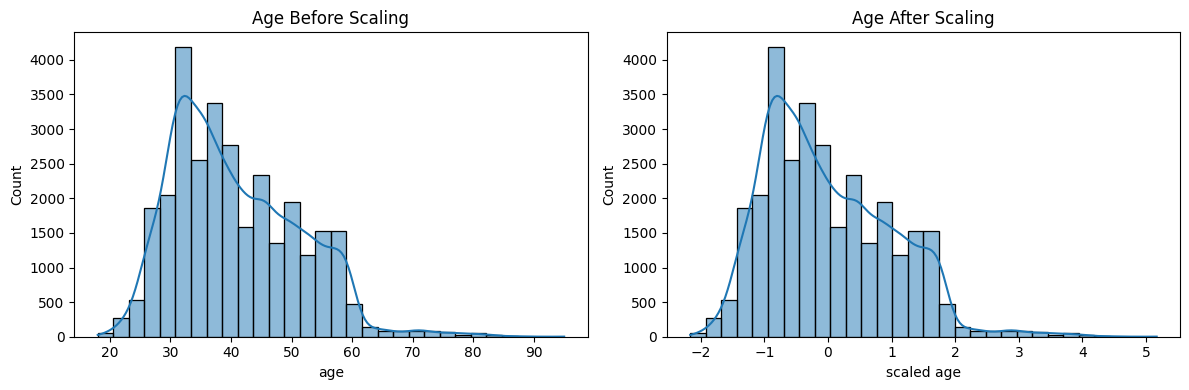

In [132]:
# Data Preprocessing Step 5: Feature Scaling
# Work through numeric columns one at a time. Start with age.

# 1. Age: inspect the training-set distribution before scaling.
train_age_before_scaling = train_df['age'].copy()
print(f"Age mean before scaling (train): {train_age_before_scaling.mean():.4f}")
print(f"Age std before scaling (train): {train_age_before_scaling.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_age_before_scaling, bins=30, kde=True, ax=axes[0])
axes[0].set_title('Age Before Scaling')
axes[0].set_xlabel('age')

# Apply standardization using training-set statistics only.
age_scaler = StandardScaler()
train_df[['age']] = age_scaler.fit_transform(train_df[['age']])
val_df[['age']] = age_scaler.transform(val_df[['age']])
test_df[['age']] = age_scaler.transform(test_df[['age']])

sns.histplot(train_df['age'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Age After Scaling')
axes[1].set_xlabel('scaled age')

plt.tight_layout()
save_plot('age_scaling_distribution.png')
plt.show()


Balance mean before scaling (train): 1331.0597
Balance std before scaling (train): 2986.7091


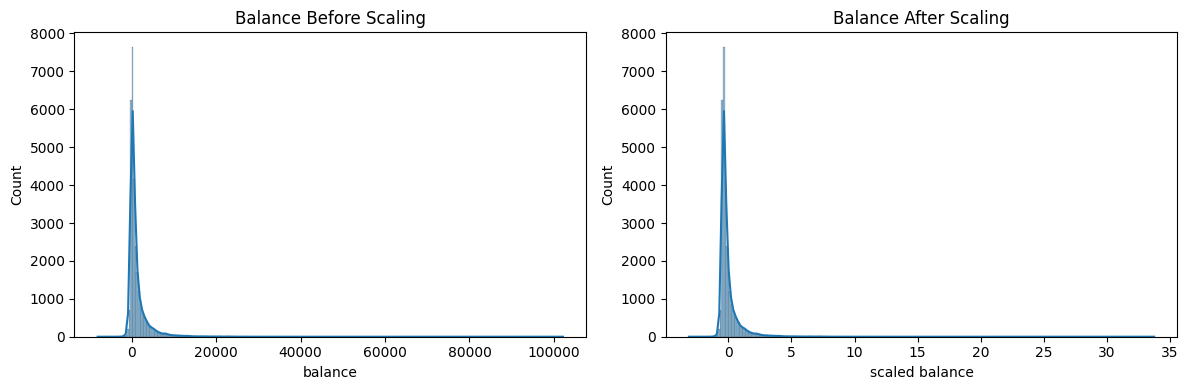

In [133]:
# 2. Balance Standardization
train_balance_before_scaling = train_df['balance'].copy()
print(f"Balance mean before scaling (train): {train_balance_before_scaling.mean():.4f}")
print(f"Balance std before scaling (train): {train_balance_before_scaling.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_balance_before_scaling, bins=300, kde=True, ax=axes[0])
axes[0].set_title('Balance Before Scaling')
axes[0].set_xlabel('balance')

# Apply standardization using training-set statistics only.
balance_scaler = StandardScaler()
train_df[['balance']]= balance_scaler.fit_transform(train_df[['balance']])
val_df[['balance']] = balance_scaler.transform(val_df[['balance']])
test_df[['balance']] = balance_scaler.transform(test_df[['balance']])

sns.histplot(train_df['balance'], bins=300, kde=True, ax=axes[1])
axes[1].set_title('Balance After Scaling')
axes[1].set_xlabel('scaled balance')

plt.tight_layout()
save_plot('balance_scaling_distribution.png')
plt.show()


Duration mean before scaling (train): 258.3133
Duration std before scaling (train): 258.7160


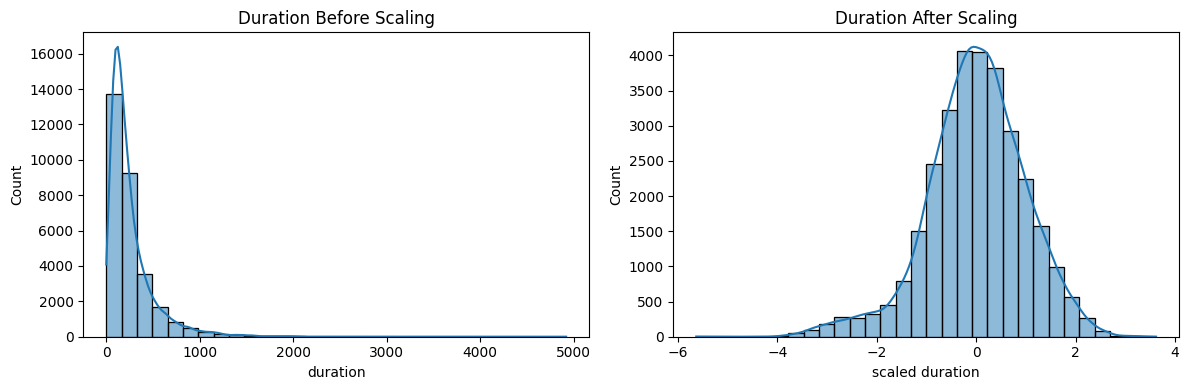

In [134]:
# 3. Duration Standardization
train_duration_before_scaling = train_df['duration'].copy()
print(f"Duration mean before scaling (train): {train_duration_before_scaling.mean():.4f}")
print(f"Duration std before scaling (train): {train_duration_before_scaling.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_duration_before_scaling, bins=30, kde=True, ax=axes[0])
axes[0].set_title('Duration Before Scaling')
axes[0].set_xlabel('duration')

# We notice is skewed so applied log transformation
train_df['duration'] = np.log(train_df['duration'] + 1)
val_df['duration'] = np.log(val_df['duration'] + 1)
test_df['duration'] = np.log(test_df['duration'] + 1)

# Apply standardization using training-set statistics only.
duration_scaler = StandardScaler()
train_df[['duration']] = duration_scaler.fit_transform(train_df[['duration']])
val_df[['duration']] = duration_scaler.transform(val_df[['duration']])
test_df[['duration']] = duration_scaler.transform(test_df[['duration']])

# Check the distribution of the transformed duration
sns.histplot(train_df['duration'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Duration After Scaling')
axes[1].set_xlabel('scaled duration')

plt.tight_layout()
save_plot('duration_scaling_distribution.png')
plt.show()


Campaign mean before scaling (train): 2.7648
Campaign std before scaling (train): 3.0985


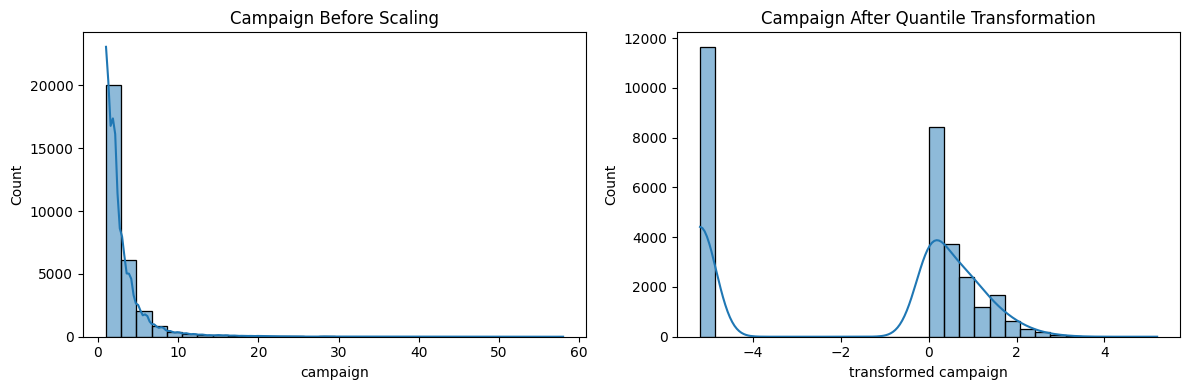

In [135]:
# 4. Campaign Scaling
train_campaign_before_scaling = train_df['campaign'].copy()
print(f"Campaign mean before scaling (train): {train_campaign_before_scaling.mean():.4f}")
print(f"Campaign std before scaling (train): {train_campaign_before_scaling.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_campaign_before_scaling, bins=30, kde=True, ax=axes[0])
axes[0].set_title('Campaign Before Scaling')
axes[0].set_xlabel('campaign')

# QuantileTransformer is used because the data is highly skewed and discrete; 
# it forces the distribution into a Gaussian (Normal) shape, 
# which is often more effective for MLP convergence than a simple log transform.
campaign_transformer = QuantileTransformer(output_distribution='normal', random_state=42)
train_df[['campaign']] = campaign_transformer.fit_transform(train_df[['campaign']])
val_df[['campaign']] = campaign_transformer.transform(val_df[['campaign']])
test_df[['campaign']] = campaign_transformer.transform(test_df[['campaign']])

# Check the distribution of the transformed campaign
sns.histplot(train_df['campaign'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Campaign After Quantile Transformation')
axes[1].set_xlabel('transformed campaign')

plt.tight_layout()
save_plot('campaign_scaling_distribution.png')
plt.show()

# Apply standardization using training-set statistics only.
campaign_scaler = StandardScaler()
train_df[['campaign']] = campaign_scaler.fit_transform(train_df[['campaign']])
val_df[['campaign']] = campaign_scaler.transform(val_df[['campaign']])
test_df[['campaign']] = campaign_scaler.transform(test_df[['campaign']])


Previous mean before scaling (train): 0.5831
Previous std before scaling (train): 1.9337


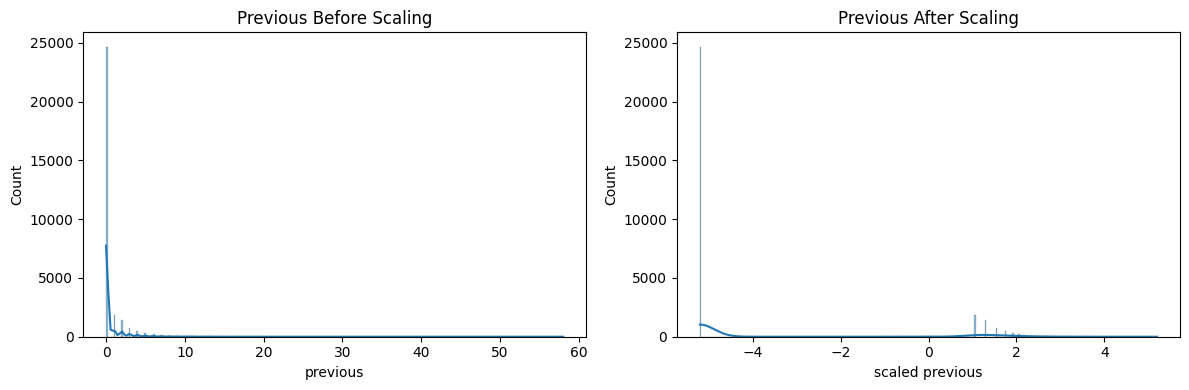

In [136]:
# 5. Previous Standardization
train_previous_before_scaling = train_df['previous'].copy()
print(f"Previous mean before scaling (train): {train_previous_before_scaling.mean():.4f}")
print(f"Previous std before scaling (train): {train_previous_before_scaling.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_previous_before_scaling, bins=300, kde=True, ax=axes[0])
axes[0].set_title('Previous Before Scaling')
axes[0].set_xlabel('previous')

# apply log transformation
previous_transformer = QuantileTransformer(output_distribution='normal', random_state=42)
train_df['previous'] = previous_transformer.fit_transform(train_df[['previous']])
val_df['previous'] = previous_transformer.transform(val_df[['previous']])
test_df['previous'] = previous_transformer.transform(test_df[['previous']])

# check the distribution of the transformed previous
sns.histplot(train_df['previous'], bins=300, kde=True, ax=axes[1])
axes[1].set_title('Previous After Scaling')
axes[1].set_xlabel('scaled previous')

plt.tight_layout()
save_plot('previous_scaling_distribution.png')
plt.show()

# Apply standardization using training-set statistics only.
previous_scaler = StandardScaler()
train_df[['previous']] = previous_scaler.fit_transform(train_df[['previous']])
val_df[['previous']] = previous_scaler.transform(val_df[['previous']])
test_df[['previous']] = previous_scaler.transform(test_df[['previous']])

Pdays mean before scaling (train): 40.6060
Pdays std before scaling (train): 100.4177


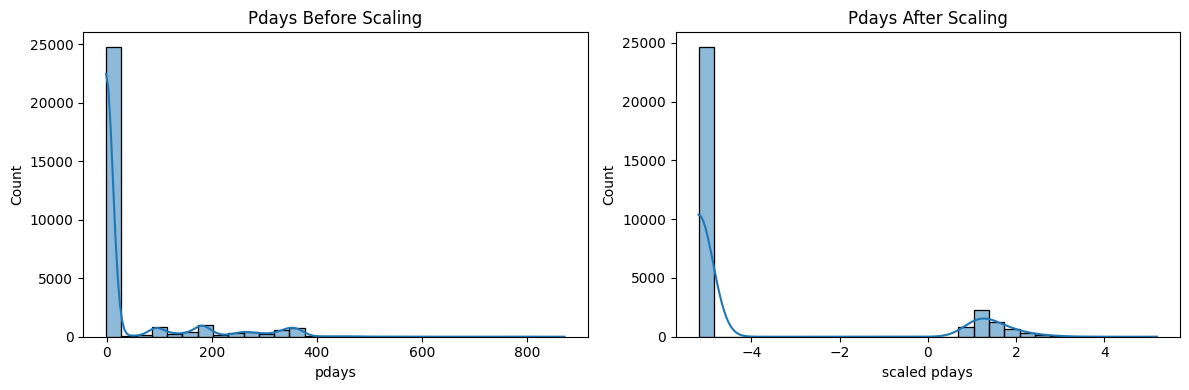

In [137]:
# 6. Pdays Standardization
train_pdays_before_scaling = train_df['pdays'].copy()
print(f"Pdays mean before scaling (train): {train_pdays_before_scaling.mean():.4f}")
print(f"Pdays std before scaling (train): {train_pdays_before_scaling.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_pdays_before_scaling, bins=30, kde=True, ax=axes[0])
axes[0].set_title('Pdays Before Scaling')
axes[0].set_xlabel('pdays')

# apply quantile transformation
pdays_transformer = QuantileTransformer(output_distribution='normal', random_state=42)
train_df[['pdays']] = pdays_transformer.fit_transform(train_df[['pdays']])
val_df[['pdays']] = pdays_transformer.transform(val_df[['pdays']])
test_df[['pdays']] = pdays_transformer.transform(test_df[['pdays']])

# check the distribution of the transformed pdays
sns.histplot(train_df['pdays'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Pdays After Scaling')
axes[1].set_xlabel('scaled pdays')

plt.tight_layout()
save_plot('pdays_scaling_distribution.png')
plt.show()

# Apply Standardization using training-set statistics only.
pdays_scaler = StandardScaler()
train_df[['pdays']] = pdays_scaler.fit_transform(train_df[['pdays']])
val_df[['pdays']] = pdays_scaler.transform(val_df[['pdays']])
test_df[['pdays']] = pdays_scaler.transform(test_df[['pdays']])

In [138]:
#  Store the scaled data in a new csv file for MLP
train_df.to_csv('scaled_train_bank_marketing.csv', index=False)
val_df.to_csv('scaled_val_bank_marketing.csv', index=False)
test_df.to_csv('scaled_test_bank_marketing.csv', index=False)

# print the shape of the scaled data
print(train_df.shape)

(30235, 32)


## 2. Gradient Boosted Tree (GBDT)

In this section, we refactor the GBDT training process to analyze model performance, feature importance, and hyperparameter effects systematically.

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import time
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    precision_recall_curve, auc, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

IMAGES_DIR = Path('images')
IMAGES_DIR.mkdir(exist_ok=True)


def save_plot(filename):
    plt.savefig(IMAGES_DIR / filename, dpi=300, bbox_inches='tight')

# Load data
train_df = pd.read_csv('scaled_train_bank_marketing.csv')
val_df = pd.read_csv('scaled_val_bank_marketing.csv')
test_df = pd.read_csv('scaled_test_bank_marketing.csv')

X_train, y_train = train_df.drop('y', axis=1), train_df['y']
X_val, y_val = val_df.drop('y', axis=1), val_df['y']
X_test, y_test = test_df.drop('y', axis=1), test_df['y']

def run_xgb_experiment(params, X_train, y_train, X_val, y_val, X_test, y_test, verbose=False):
    start_time = time.time()
    
    # Initialize model
    model = xgb.XGBClassifier(**params, random_state=42)
    model.fit(
        X_train, y_train, 
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=verbose
    )
    
    training_time = time.time() - start_time
    
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC-PR': auc(recall, precision),
        'training_time': training_time,
        'best_iteration': model.best_iteration if hasattr(model, 'best_iteration') else params.get('n_estimators')
    }
    
    return model, metrics, (precision, recall, cm)

### 2.1 Base Model Analysis

We train a base model with the following parameters:
- `learning_rate=0.05`
- `n_estimators=1000`
- `max_depth=4`
- `subsample=0.8`
- `colsample_bytree=0.8`
- `reg_alpha=0`
- `reg_lambda=1`

Base Model Metrics:
Accuracy: 0.9150
Precision: 0.6826
Recall: 0.4960
F1: 0.5745
AUC-PR: 0.6570
training_time: 0.6332
best_iteration: 386


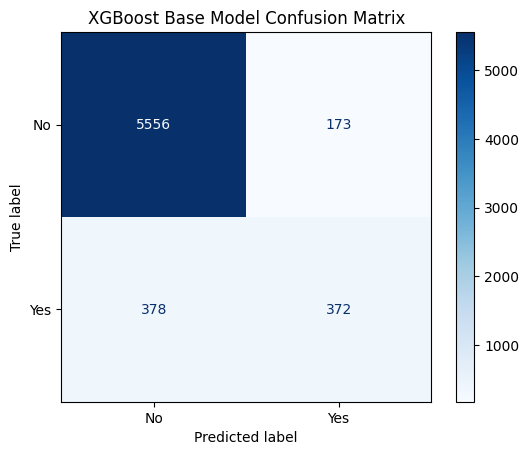

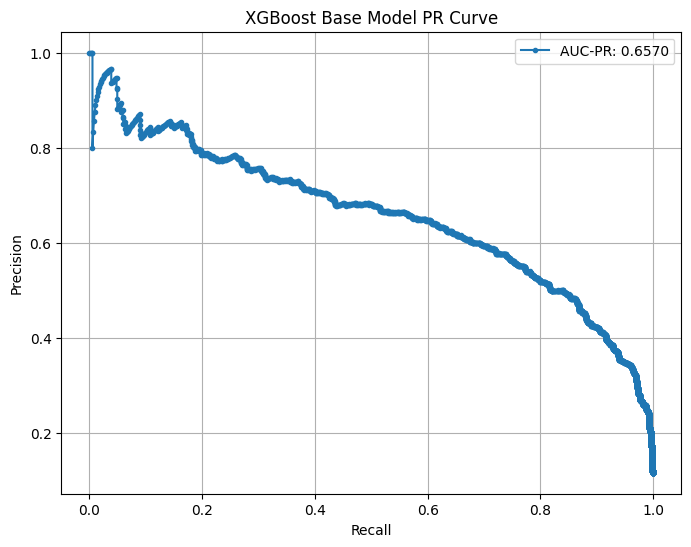

In [140]:
base_params = {
    'learning_rate': 0.05,
    'n_estimators': 1000,
    'max_depth': 4,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0,
    'reg_lambda': 1,
    'eval_metric': 'logloss',
    'early_stopping_rounds': 50
}

base_model, base_metrics, base_pr_curve = run_xgb_experiment(
    base_params, X_train, y_train, X_val, y_val, X_test, y_test, verbose=False
)

print("Base Model Metrics:")
for k, v in base_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

precision, recall, cm = base_pr_curve
# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap='Blues')
plt.title('XGBoost Base Model Confusion Matrix')
save_plot('xgboost_base_confusion_matrix.png')
plt.show()

# Display PR Curve and AUC-PR
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f"AUC-PR: {base_metrics['AUC-PR']:.4f}")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('XGBoost Base Model PR Curve')
plt.legend()
plt.grid(True)
save_plot('xgboost_base_pr_curve.png')
plt.show()

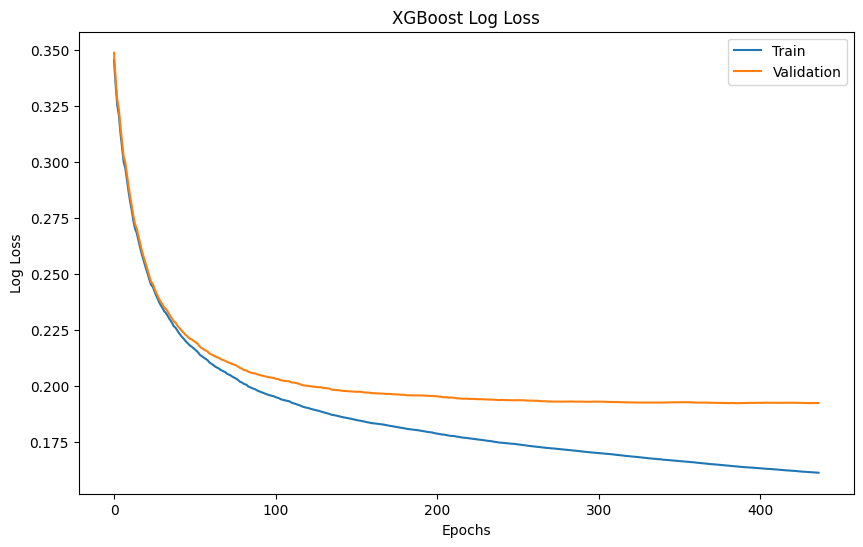

In [141]:
# Plot training vs validation loss
results = base_model.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(10, 6))
plt.plot(x_axis, results['validation_0']['logloss'], label='Train')
plt.plot(x_axis, results['validation_1']['logloss'], label='Validation')
plt.legend()
plt.ylabel('Log Loss')
plt.xlabel('Epochs')
plt.title('XGBoost Log Loss')
save_plot('xgboost_log_loss.png')
plt.show()

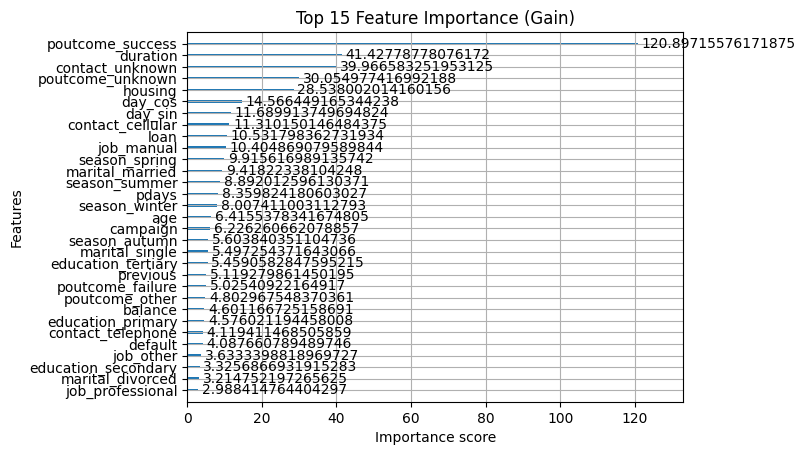

In [ ]:
# Analyze feature importance (top 15, importance_type='gain')
xgb.plot_importance(base_model, max_num_features=32, importance_type='gain', title='Feature Importance (Gain)')
save_plot('xgboost_feature_importance_gain.png')
plt.show()

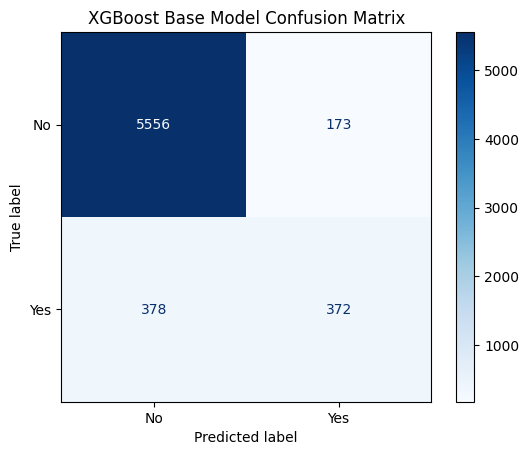

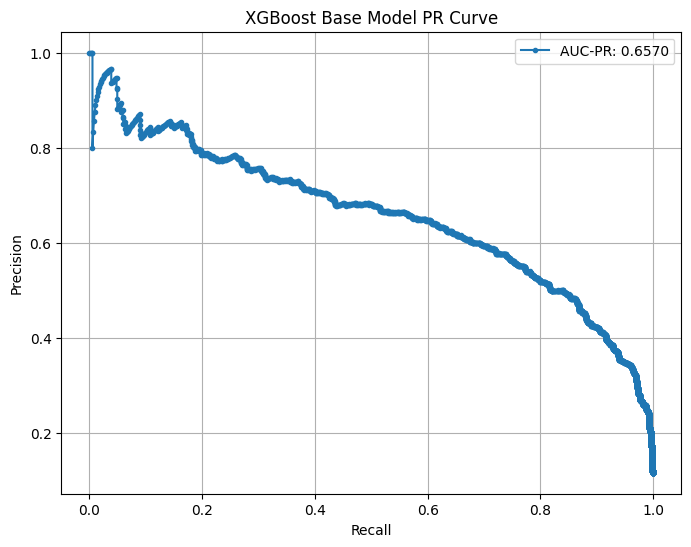

In [143]:
precision, recall, cm = base_pr_curve
# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap='Blues')
plt.title('XGBoost Base Model Confusion Matrix')
save_plot('xgboost_base_confusion_matrix_repeat.png')
plt.show()

# Display PR Curve and AUC-PR
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f"AUC-PR: {base_metrics['AUC-PR']:.4f}")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('XGBoost Base Model PR Curve')
plt.legend()
plt.grid(True)
save_plot('xgboost_base_pr_curve_repeat.png')
plt.show()

### 2.2 Learning Rate Visualization

We compare the validation loss curves for different learning rates: `[0.01, 0.05, 0.1, 0.3]`.

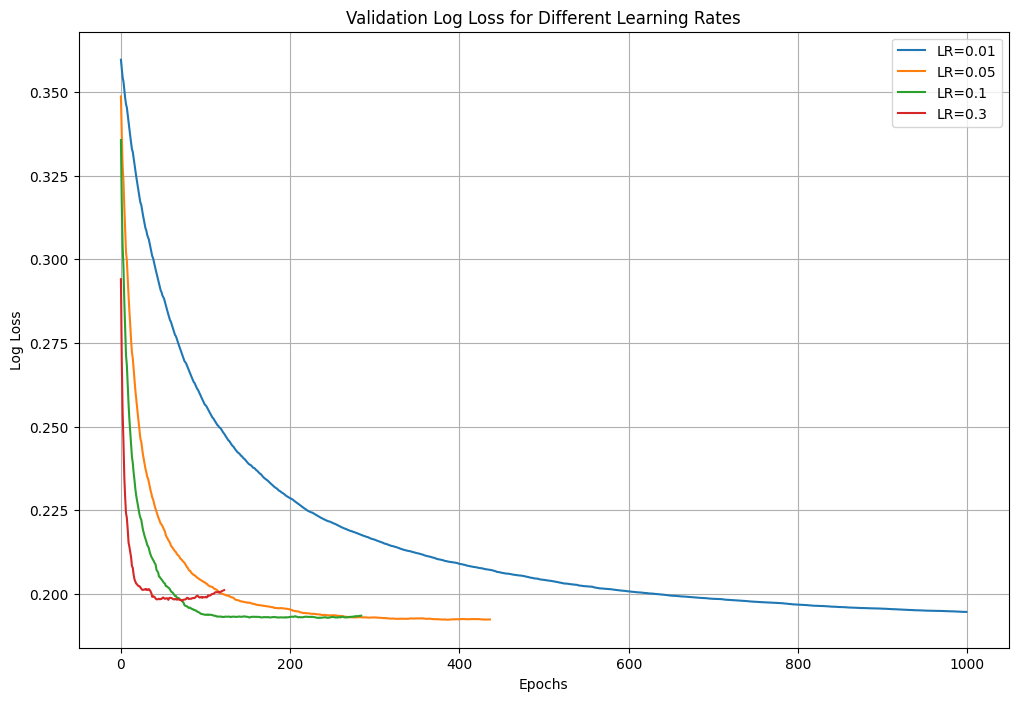

In [144]:
learning_rates = [0.01, 0.05, 0.1, 0.3]
plt.figure(figsize=(12, 8))

for lr in learning_rates:
    params = base_params.copy()
    params['learning_rate'] = lr
    # Use early stopping for each learning rate to see training progression
    model, metrics, _ = run_xgb_experiment(params, X_train, y_train, X_val, y_val, X_test, y_test)
    
    results = model.evals_result()
    val_loss = results['validation_1']['logloss']
    plt.plot(val_loss, label=f'LR={lr}')

plt.title('Validation Log Loss for Different Learning Rates')
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
save_plot('xgboost_learning_rate_validation_log_loss.png')
plt.show()

### 2.3 Parameter Comparison

We compare various parameters and summarize their impact in a single table.

In [145]:
experiments = [
    ("Base Model", base_params),
    ("Max Depth 3", {**base_params, 'max_depth': 3}),
    ("Max Depth 10", {**base_params, 'max_depth': 10}),
    ("Max Depth 15", {**base_params, 'max_depth': 15}),
    ("Subsample 0.1", {**base_params, 'subsample': 0.1}),
    ("Subsample 0.5", {**base_params, 'subsample': 0.5}),
    ("Subsample 1.0", {**base_params, 'subsample': 1.0}),
    ("Reg Alpha 0.01", {**base_params, 'reg_alpha': 0.01}),
    ("Reg Alpha 0.1", {**base_params, 'reg_alpha': 0.1}),
    ("Reg Alpha 1.0", {**base_params, 'reg_alpha': 1.0}),
    ("Reg Lambda 0.1", {**base_params, 'reg_lambda': 0.1}),
    ("Reg Lambda 1.0", {**base_params, 'reg_lambda': 1.0}),
    ("Reg Lambda 10.0", {**base_params, 'reg_lambda': 10.0}),
    ("N_Estimators 100", {**base_params, 'n_estimators': 100}),
    ("N-Estimators 500", {**base_params, 'n_estimators': 500}),
    ("N-Estimators 1500", {**base_params, 'n_estimators': 1500})
]

summary_data = []

for name, params in experiments:
    _, metrics, _ = run_xgb_experiment(params, X_train, y_train, X_val, y_val, X_test, y_test)
    summary_data.append({
        'Experiment': name,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1': metrics['F1'],
        'Training Time (s)': metrics['training_time']
    })

df_summary = pd.DataFrame(summary_data)
display(df_summary)

,Experiment,Accuracy,Precision,Recall,F1,Training Time (s)
0,Base Model,0.914956,0.682569,0.496000,0.574517,0.632626
1,Max Depth 3,0.914184,0.686538,0.476000,0.562205,0.756843
2,Max Depth 10,0.911097,0.655914,0.488000,0.559633,0.460285
3,Max Depth 15,0.909245,0.654580,0.457333,0.538462,0.754803
4,Subsample 0.1,0.910943,0.669276,0.456000,0.542427,0.557842
5,Subsample 0.5,0.914956,0.683241,0.494667,0.573859,0.452086
6,Subsample 1.0,0.912950,0.674157,0.480000,0.560748,0.644568
7,Reg Alpha 0.01,0.912641,0.669742,0.484000,0.561920,0.579842
8,Reg Alpha 0.1,0.914339,0.672566,0.506667,0.577947,0.686319
9,Reg Alpha 1.0,0.916191,0.686486,0.508000,0.583908,0.596177


## 3. Multilayer Perceptron (MLP)

In this section, we train and evaluate a Multilayer Perceptron (MLP) using scikit-learn. We explore the impact of various hyperparameters on the model's performance.

In [146]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

def run_mlp_experiment(params, X_train, y_train, X_val, y_val, X_test, y_test):
    start_time = time.time()
    
    # Initialize and train model
    model = MLPClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    
    training_time = time.time() - start_time
    
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC-PR': auc(recall, precision),
        'training_time': training_time
    }
    
    return model, metrics, (precision, recall, cm)

### 3.1 Tuned MLP Model Analysis

We use `GridSearchCV` with stratified 3-fold cross-validation to tune the MLP hyperparameters on the training split. The best configuration is stored in `base_params_mlp` and then evaluated on the held-out test set.

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best MLP Parameters:
activation: relu
alpha: 0.01
hidden_layer_sizes: (64, 32)
learning_rate_init: 0.001
max_iter: 100
early_stopping: True
n_iter_no_change: 20

Tuned MLP Metrics:
CV F1: 0.5380
Accuracy: 0.9052
Precision: 0.6298
Recall: 0.4400
F1: 0.5181
AUC-PR: 0.6002
training_time: 228.8298


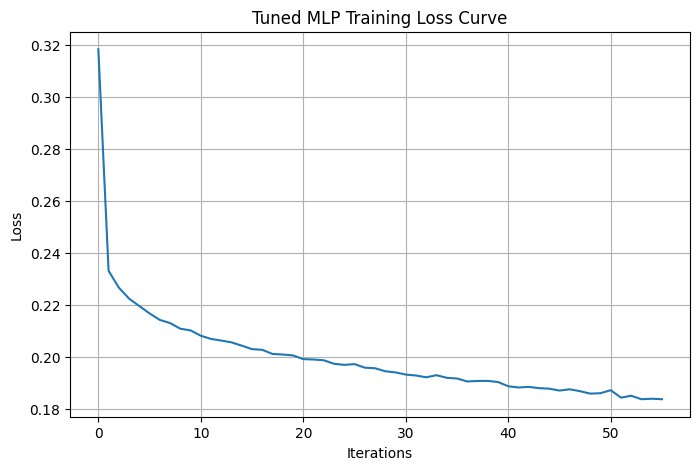

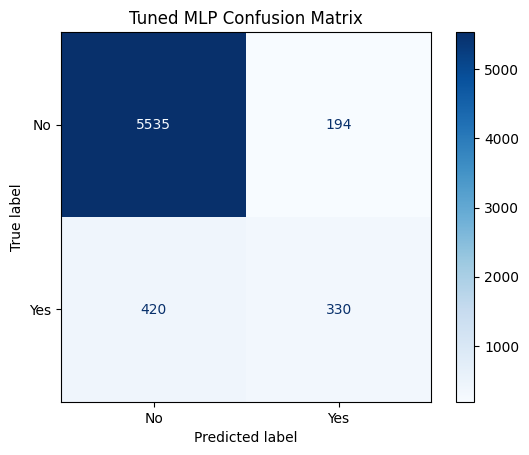

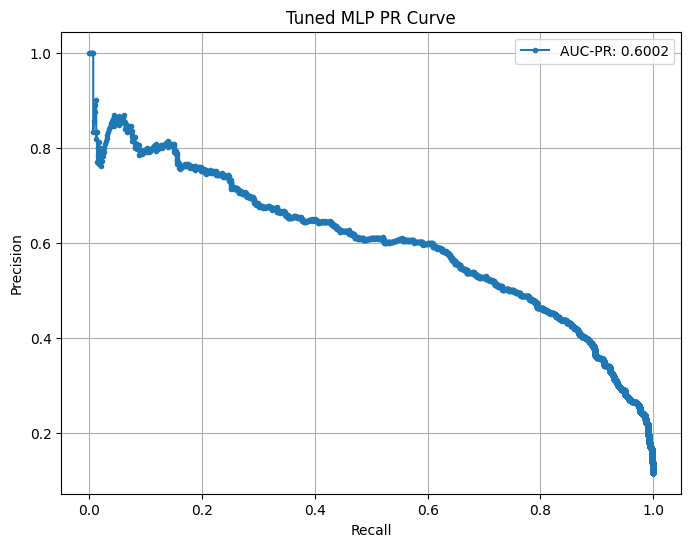

In [147]:
mlp_param_grid = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (128, 64, 32)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.001, 0.01, 0.1],
    'learning_rate_init': [0.001, 0.01, 0.1, 1.0],
    'max_iter': [100, 300, 500]
}

mlp_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
mlp_grid_search = GridSearchCV(
    estimator=MLPClassifier(random_state=42, early_stopping=True, n_iter_no_change=20),
    param_grid=mlp_param_grid,
    scoring='f1',
    cv=mlp_cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

mlp_search_start = time.time()
mlp_grid_search.fit(X_train, y_train)
mlp_search_time = time.time() - mlp_search_start

base_params_mlp = {
    **mlp_grid_search.best_params_,
    'early_stopping': True,
    'n_iter_no_change': 20
}
mlp_base_model = mlp_grid_search.best_estimator_

# Evaluate the tuned model on the held-out test set.
y_pred = mlp_base_model.predict(X_test)
y_prob = mlp_base_model.predict_proba(X_test)[:, 1]
mlp_precision, mlp_recall, _ = precision_recall_curve(y_test, y_prob)
mlp_cm = confusion_matrix(y_test, y_pred)

mlp_base_metrics = {
    'CV F1': mlp_grid_search.best_score_,
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'AUC-PR': auc(mlp_recall, mlp_precision),
    'training_time': mlp_search_time
}

print("Best MLP Parameters:")
for k, v in base_params_mlp.items():
    print(f"{k}: {v}")

print("\nTuned MLP Metrics:")
for k, v in mlp_base_metrics.items():
    print(f"{k}: {v:.4f}")

# Plot Training Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(mlp_base_model.loss_curve_)
plt.title('Tuned MLP Training Loss Curve')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=mlp_cm, display_labels=['No', 'Yes'])
disp.plot(cmap='Blues')
plt.title('Tuned MLP Confusion Matrix')
plt.show()

# Display PR Curve
plt.figure(figsize=(8, 6))
plt.plot(mlp_recall, mlp_precision, marker='.', label=f"AUC-PR: {mlp_base_metrics['AUC-PR']:.4f}")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Tuned MLP PR Curve')
plt.legend()
plt.grid(True)
plt.show()

### 3.2 GridSearchCV Results Summary

The table below summarizes the highest-ranked hyperparameter combinations found by `GridSearchCV`, ordered by cross-validated F1 score.

In [148]:
df_mlp_summary = (
    pd.DataFrame(mlp_grid_search.cv_results_)
    .sort_values('rank_test_score')
    [[
        'rank_test_score',
        'mean_test_score',
        'std_test_score',
        'param_hidden_layer_sizes',
        'param_activation',
        'param_alpha',
        'param_learning_rate_init',
        'param_max_iter'
    ]]
    .rename(columns={
        'rank_test_score': 'Rank',
        'mean_test_score': 'Mean CV F1',
        'std_test_score': 'Std CV F1',
        'param_hidden_layer_sizes': 'Hidden Layers',
        'param_activation': 'Activation',
        'param_alpha': 'Alpha',
        'param_learning_rate_init': 'Learning Rate',
        'param_max_iter': 'Max Iter'
    })
)

display(df_mlp_summary.head(10))

,Rank,Mean CV F1,Std CV F1,Hidden Layers,Activation,Alpha,Learning Rate,Max Iter
36,1,0.538035,0.005559,"(64, 32)",relu,0.010,0.001,100
38,1,0.538035,0.005559,"(64, 32)",relu,0.010,0.001,500
37,1,0.538035,0.005559,"(64, 32)",relu,0.010,0.001,300
51,4,0.536085,0.009248,"(128, 64)",relu,0.010,0.010,100
52,4,0.536085,0.009248,"(128, 64)",relu,0.010,0.010,300
53,4,0.536085,0.009248,"(128, 64)",relu,0.010,0.010,500
195,7,0.535510,0.008886,"(128, 64)",tanh,0.100,0.010,100
196,7,0.535510,0.008886,"(128, 64)",tanh,0.100,0.010,300
197,7,0.535510,0.008886,"(128, 64)",tanh,0.100,0.010,500
14,10,0.530975,0.025309,"(128, 64)",relu,0.001,0.001,500


### 3.3 Effect of Network Architecture

Visualizing how network depth and width influence validation performance.

,Architecture,Accuracy,Precision,Recall,F1,Training Time (s)
0,64,0.9079,0.7040,0.3520,0.4693,1.3998
1,128,0.9055,0.6228,0.4667,0.5335,2.5561
2,"64, 32",0.9052,0.6298,0.4400,0.5181,3.6312
3,"128, 64",0.9057,0.6415,0.4200,0.5077,5.4469
4,"128, 64, 32",0.9080,0.6878,0.3760,0.4862,6.1189


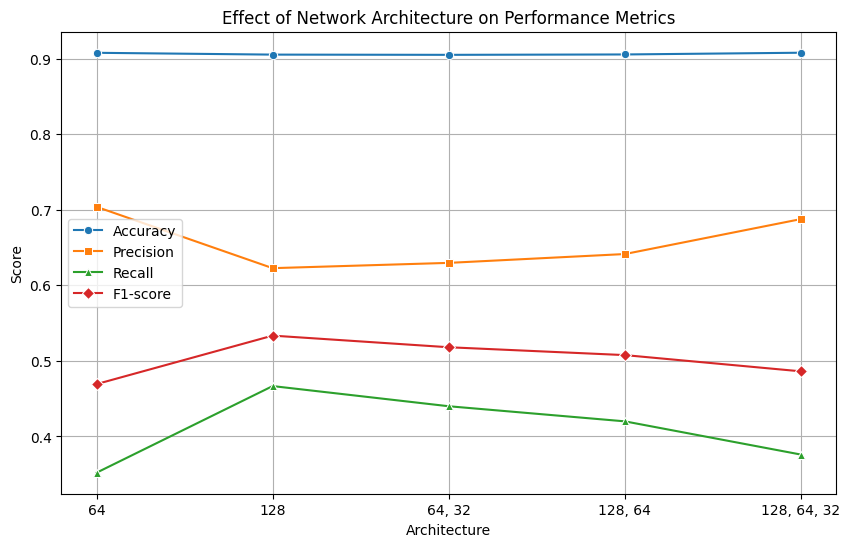

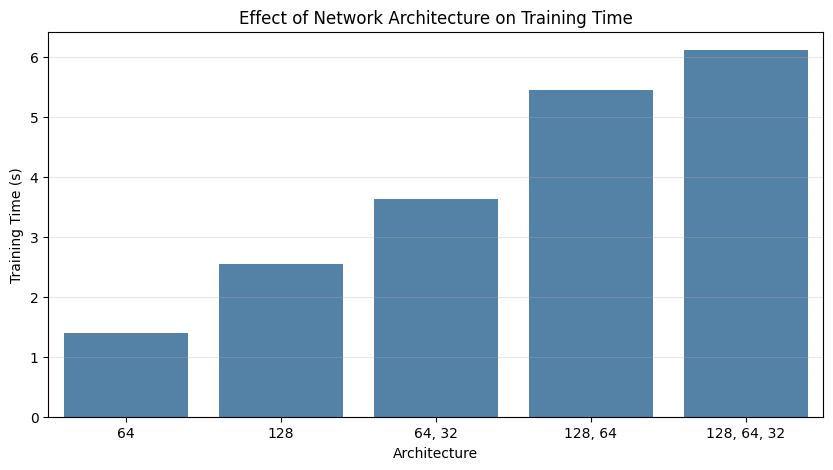

In [155]:
arch_experiments = [
    ("64", (64,)),
    ("128", (128,)),
    ("64, 32", (64, 32)),
    ("128, 64", (128, 64)),
    ("128, 64, 32", (128, 64, 32))
]

arch_results = []
for name, arch in arch_experiments:
    params = {**base_params_mlp, 'hidden_layer_sizes': arch}
    _, metrics, _ = run_mlp_experiment(params, X_train, y_train, X_val, y_val, X_test, y_test)
    arch_results.append({
        'Architecture': name,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1': metrics['F1'],
        'Training Time (s)': metrics['training_time']
    })

df_arch = pd.DataFrame(arch_results)
df_arch[['Accuracy', 'Precision', 'Recall', 'F1', 'Training Time (s)']] = df_arch[
    ['Accuracy', 'Precision', 'Recall', 'F1', 'Training Time (s)']
].round(4)

display(df_arch)

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_arch, x='Architecture', y='Accuracy', marker='o', label='Accuracy')
sns.lineplot(data=df_arch, x='Architecture', y='Precision', marker='s', label='Precision')
sns.lineplot(data=df_arch, x='Architecture', y='Recall', marker='^', label='Recall')
sns.lineplot(data=df_arch, x='Architecture', y='F1', marker='D', label='F1-score')
plt.title('Effect of Network Architecture on Performance Metrics')
plt.ylabel('Score')
plt.grid(True)
plt.legend()
save_plot('effect_of_network_architecture_on_performance_metrics.png')
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=df_arch, x='Architecture', y='Training Time (s)', color='steelblue')
plt.title('Effect of Network Architecture on Training Time')
plt.ylabel('Training Time (s)')
plt.grid(axis='y', alpha=0.3)
save_plot('effect_of_network_architecture_on_training_time.png')
plt.show()

## 4. Final Model Comparison

Comparison of XGBoost and MLP base models.

,Model,Accuracy,F1,AUC-PR
0,XGBoost (Base),0.914956,0.574517,0.657001
1,MLP (Base),0.905232,0.518053,0.600187


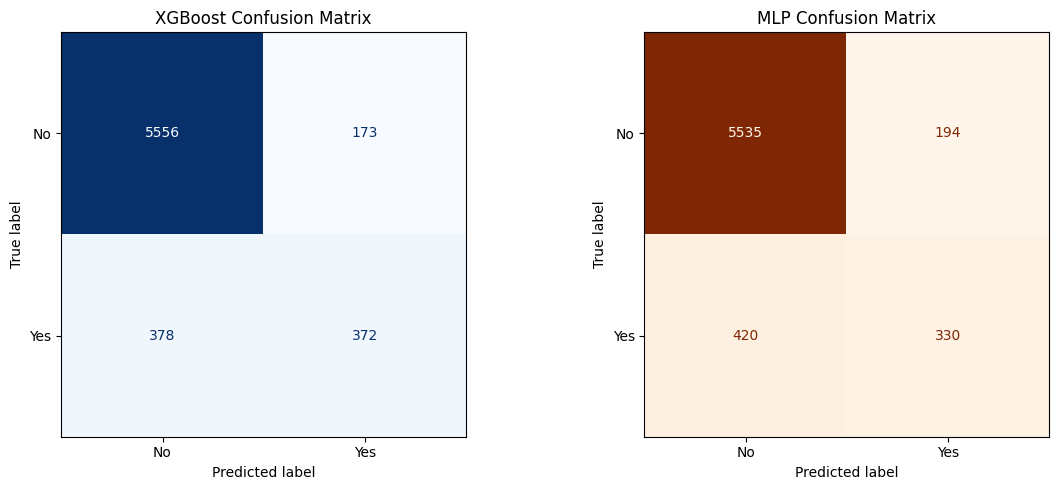

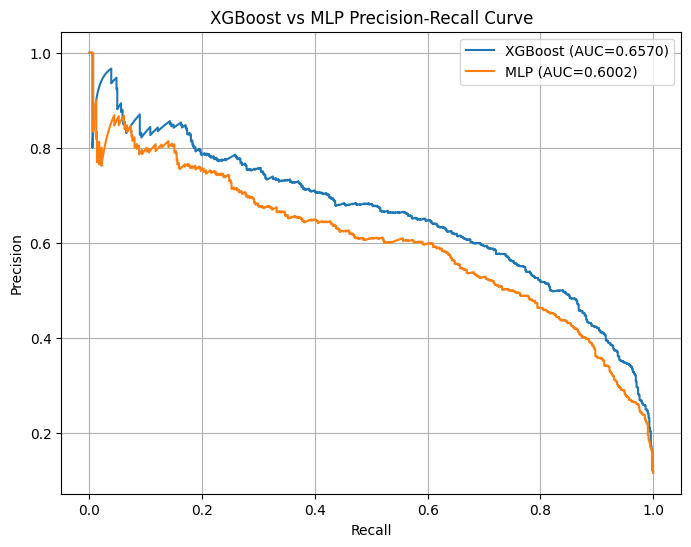

In [150]:
comparison_data = [
    {
        'Model': 'XGBoost (Base)',
        'Accuracy': base_metrics['Accuracy'],
        'F1': base_metrics['F1'],
        'AUC-PR': base_metrics['AUC-PR']
    },
    {
        'Model': 'MLP (Base)',
        'Accuracy': mlp_base_metrics['Accuracy'],
        'F1': mlp_base_metrics['F1'],
        'AUC-PR': mlp_base_metrics['AUC-PR']
    }
]

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison)

# Confusion Matrix Comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes']).plot(
    cmap='Blues',
    ax=axes[0],
    colorbar=False
)
axes[0].set_title('XGBoost Confusion Matrix')

ConfusionMatrixDisplay(confusion_matrix=mlp_cm, display_labels=['No', 'Yes']).plot(
    cmap='Oranges',
    ax=axes[1],
    colorbar=False
)
axes[1].set_title('MLP Confusion Matrix')

plt.tight_layout()
plt.show()

# Plot AUC-PR Comparison
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"XGBoost (AUC={base_metrics['AUC-PR']:.4f})")
plt.plot(mlp_recall, mlp_precision, label=f"MLP (AUC={mlp_base_metrics['AUC-PR']:.4f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('XGBoost vs MLP Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()